In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load file


In [3]:
import zipfile
import pandas as pd

with zipfile.ZipFile('/content/drive/MyDrive/fraud detection dataset.zip') as z:
    print(z.namelist())
    # Move the read_csv call inside the 'with' block and use the correct filename
    df = pd.read_csv(z.open('AIML Dataset.csv'))

['AIML Dataset.csv']


# Data cleaning

In [4]:
df.shape

(6362620, 11)

In [5]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04

In [9]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


# EDA

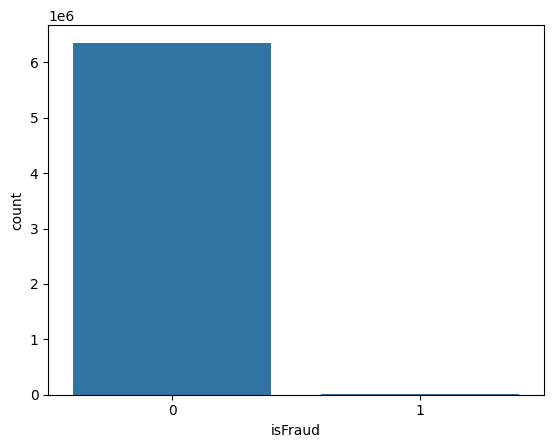

In [10]:


sns.countplot(x='isFraud', data=df)
plt.show()

In [11]:
df.groupby('type')['isFraud'].mean()

,isFraud
type,
CASH_IN,0.000000
CASH_OUT,0.001840
DEBIT,0.000000
PAYMENT,0.000000
TRANSFER,0.007688


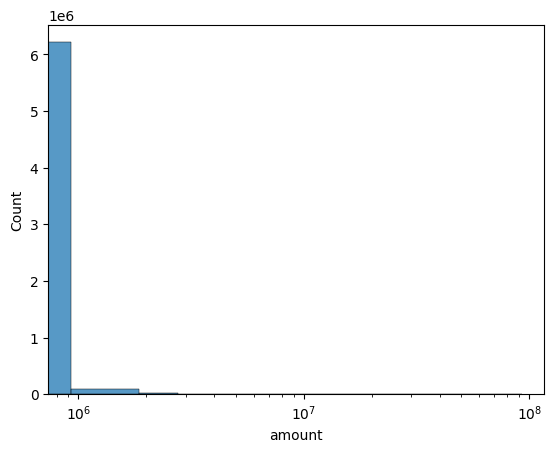

In [12]:
sns.histplot(df['amount'], bins=100)
plt.xscale('log')
plt.show()

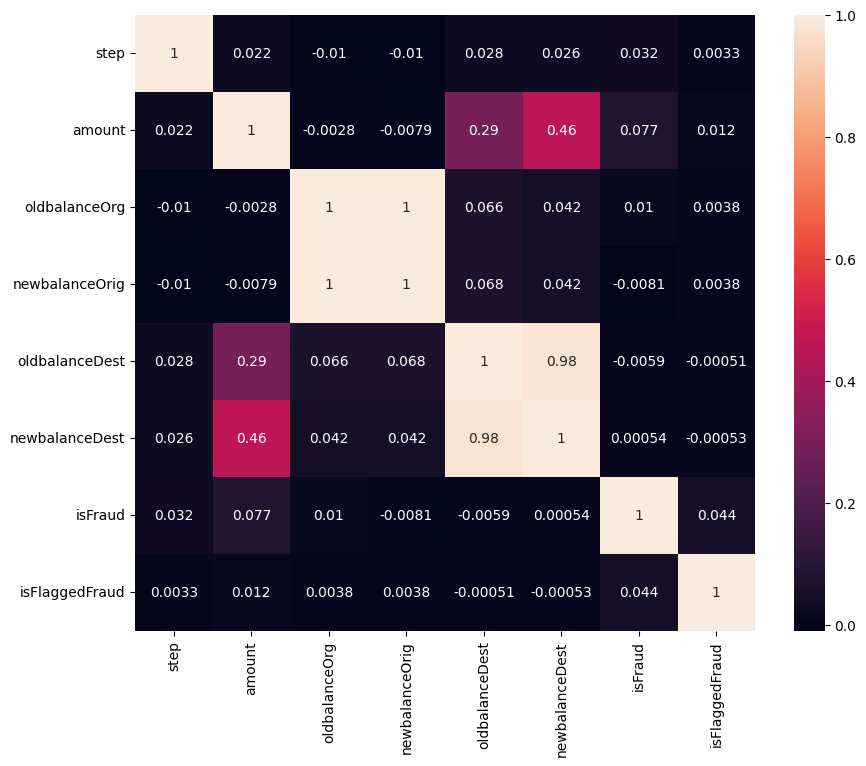

In [13]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

In [14]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

# Feature Engineering

In [15]:
df = df.drop(['nameOrig','nameDest'], axis=1)

In [16]:
df = df.drop('isFlaggedFraud', axis=1)

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [18]:
df['orig_balance_error'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
)

df['dest_balance_error'] = (
    df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']
)

In [19]:
df['hour'] = df['step'] % 24
df['day'] = df['step'] // 24

In [20]:
# Amount per hour
df['amount_per_hour'] = df['amount'] / (df['hour'] + 1)

# Balance change ratio
df['balance_change_ratio'] = (
    abs(df['oldbalanceOrg'] - df['newbalanceOrig'])
    / (df['oldbalanceOrg'] + 1)
)

# Destination balance ratio
df['dest_balance_ratio'] = (
    df['newbalanceDest']
    / (df['oldbalanceDest'] + 1)
)

# Large transaction flag
threshold_large = df['amount'].quantile(0.95)
df['is_large_transaction'] = (df['amount'] > threshold_large).astype(int)

In [21]:
df['amount'] = np.log1p(df['amount'])

In [22]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [23]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

# Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

# First split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Second split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

Train Shape: (4596992, 15)
Validation Shape: (811235, 15)
Test Shape: (954393, 15)


In [25]:
# --- ADD THIS TO REPLACE STANDARD SCALER ---
from sklearn.preprocessing import RobustScaler

# We use RobustScaler instead of StandardScaler to remain safe from massive financial outliers
scaler = RobustScaler()

# Assuming X_train and X_test are your split feature dataframes:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
pip install xgboost

# Model Training & Model Evaluation & threshold tuning

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score, # Added f1_score import
    precision_recall_curve,
    f1_score as f1_metric
)

# Calculate imbalance ratio
fraud = y_train.value_counts()[1]
normal = y_train.value_counts()[0]

scale_pos_weight = normal / fraud

# Professional fraud detection model
trained_xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=2,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Scale validation data using the fitted scaler
X_val_scaled = scaler.transform(X_val)

# Train with validation
trained_xgb_model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=True
)




[0]	validation_0-aucpr:0.95377
[1]	validation_0-aucpr:0.96140
[2]	validation_0-aucpr:0.96488
[3]	validation_0-aucpr:0.96746
[4]	validation_0-aucpr:0.96806
[5]	validation_0-aucpr:0.96805
[6]	validation_0-aucpr:0.96805
[7]	validation_0-aucpr:0.97877
[8]	validation_0-aucpr:0.99863
[9]	validation_0-aucpr:0.99937
[10]	validation_0-aucpr:0.99925
[11]	validation_0-aucpr:0.99888
[12]	validation_0-aucpr:0.99888
[13]	validation_0-aucpr:0.99897
[14]	validation_0-aucpr:0.99903
[15]	validation_0-aucpr:0.99899
[16]	validation_0-aucpr:0.99912
[17]	validation_0-aucpr:0.99884
[18]	validation_0-aucpr:0.99914
[19]	validation_0-aucpr:0.99914
[20]	validation_0-aucpr:0.99915
[21]	validation_0-aucpr:0.99914
[22]	validation_0-aucpr:0.99891
[23]	validation_0-aucpr:0.99892
[24]	validation_0-aucpr:0.99894
[25]	validation_0-aucpr:0.99894
[26]	validation_0-aucpr:0.99905
[27]	validation_0-aucpr:0.99905
[28]	validation_0-aucpr:0.99907
[29]	validation_0-aucpr:0.99911
[30]	validation_0-aucpr:0.99903
[31]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

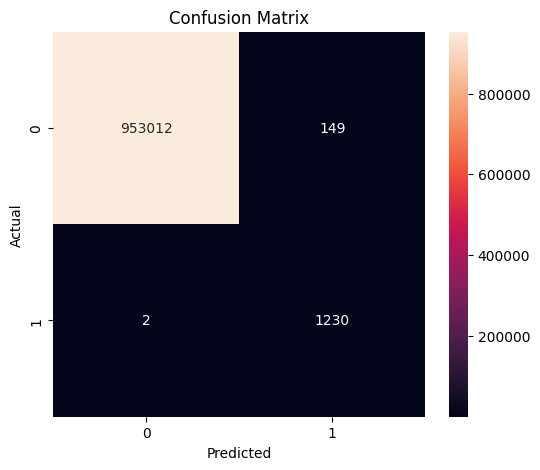

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate predictions for the test set
pred = trained_xgb_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Feature Importance

In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': trained_xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                 Feature  Importance
7     orig_balance_error    0.418331
4         newbalanceOrig    0.342337
12  balance_change_ratio    0.092895
1                   type    0.041366
2                 amount    0.033113
3          oldbalanceOrg    0.013622
11       amount_per_hour    0.011583
13    dest_balance_ratio    0.011399
8     dest_balance_error    0.009464
14  is_large_transaction    0.007054
9                   hour    0.004739
10                   day    0.003889
6         newbalanceDest    0.003537
5         oldbalanceDest    0.003429
0                   step    0.003242


In [31]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

thresholds = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

# Prediction probabilities
probs = trained_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Test fixed thresholds
for threshold in thresholds:

    pred = (probs > threshold).astype(int)

    print(f"\nThreshold: {threshold}")

    print(classification_report(y_test, pred))

# ==========================================
# FAST THRESHOLD SEARCH
# ==========================================

sampled_thresholds = np.linspace(0.1, 0.99, 100)

f1_scores = []

for t in sampled_thresholds:

    preds = (probs >= t).astype(int)

    score = f1_score(y_test, preds)

    f1_scores.append(score)

best_threshold = sampled_thresholds[np.argmax(f1_scores)]

best_f1 = np.max(f1_scores)

print("\nBest Threshold:", best_threshold)

print("Best F1 Score:", best_f1)


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.89      1.00      0.94      1232

    accuracy                           1.00    954393
   macro avg       0.95      1.00      0.97    954393
weighted avg       1.00      1.00      1.00    954393


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.93      1.00      0.96      1232

    accuracy                           1.00    954393
   macro avg       0.96      1.00      0.98    954393
weighted avg       1.00      1.00      1.00    954393


Threshold: 0.8
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.95      1.00      0.98      1232

    accuracy                           1.00    954393
   macro avg       0.98      1.00      0.99    954393
weighted avg       1.00   

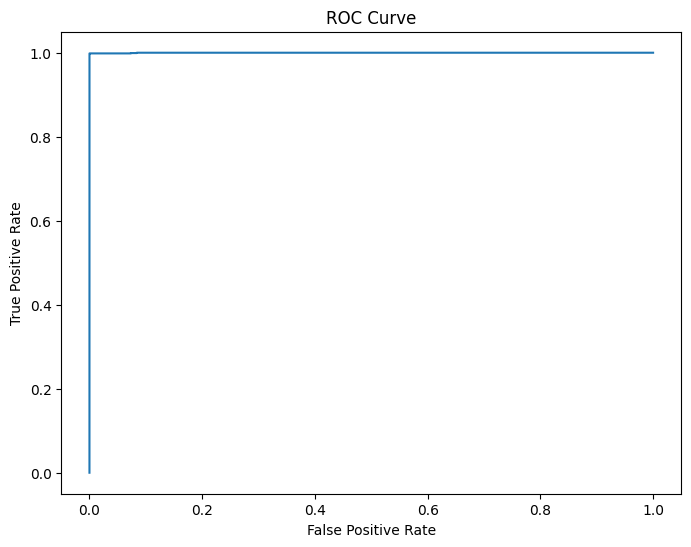

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

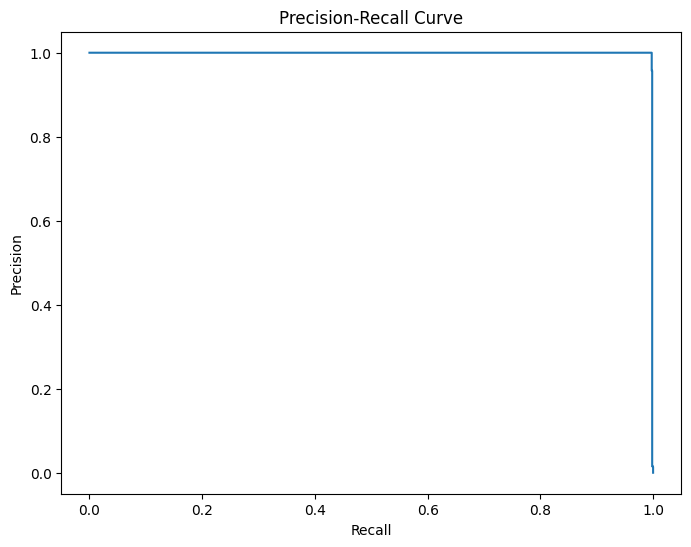

In [33]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    probs
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

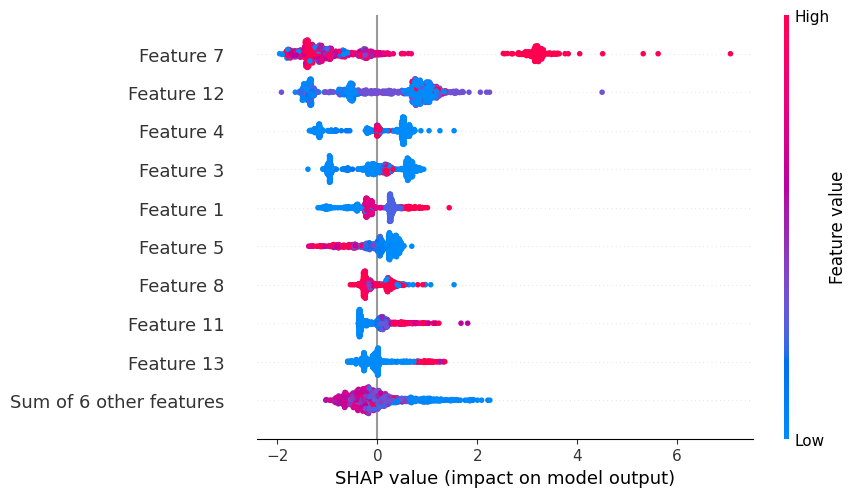

In [34]:
import shap

# Take small sample
X_sample = X_test.sample(1000, random_state=42)

# Scale the sample using the previously fitted scaler
X_sample_scaled = scaler.transform(X_sample)

# Create explainer
# Use the trained_xgb_model and its predict method
explainer = shap.Explainer(trained_xgb_model, X_sample_scaled)

# Calculate SHAP values
shap_values = explainer(X_sample_scaled)

# Plot
shap.plots.beeswarm(shap_values)

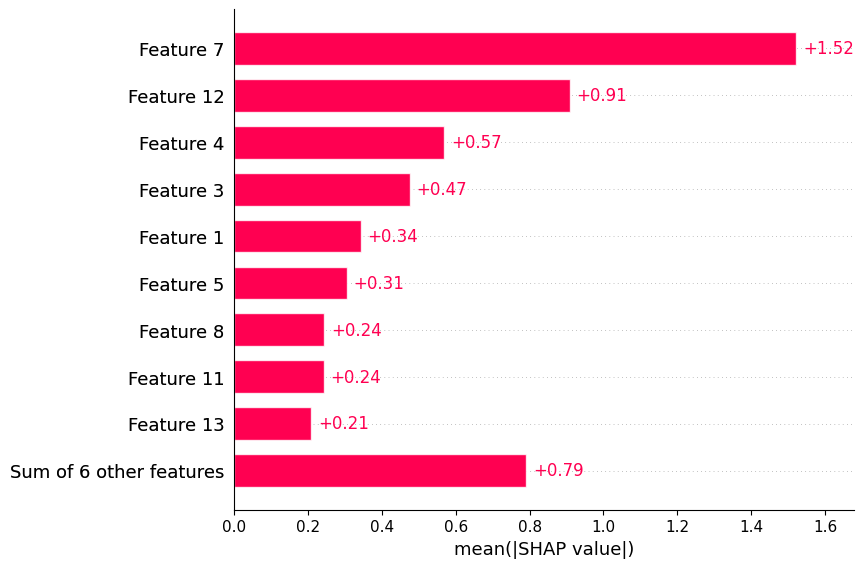

In [35]:
shap.plots.bar(shap_values)

# SHAP Explainability

SHAP analysis shows the most influential features used by the XGBoost model to detect fraudulent transactions.

Important fraud indicators include:
- Transaction amount
- Sender balance changes
- Destination balance changes
- Transaction type
- Balance inconsistencies

Higher SHAP values increase fraud probability, while lower values reduce fraud probability.

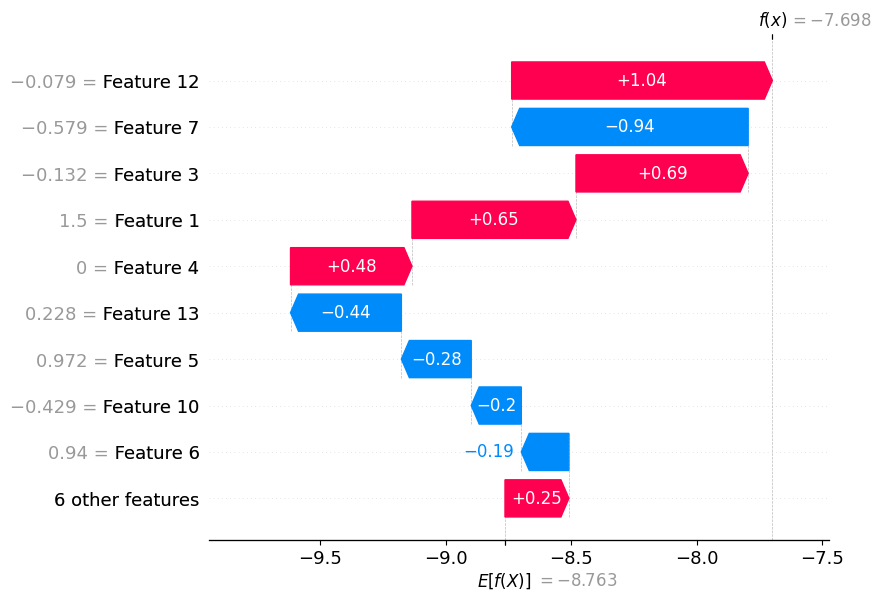

In [36]:
# Explain one fraud transaction
shap.plots.waterfall(shap_values[0])

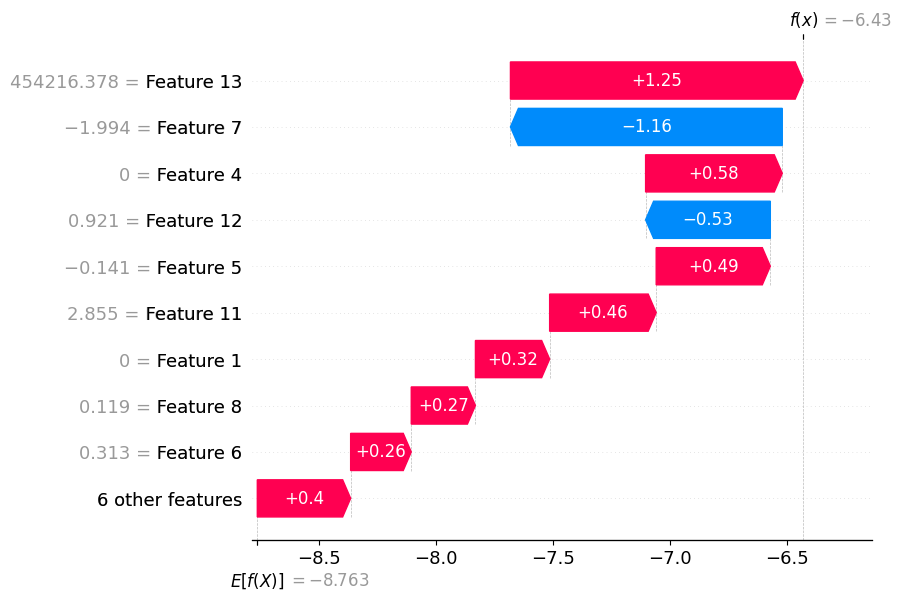

In [37]:
# Explain one normal transaction
shap.plots.waterfall(shap_values[10])

Model Evaluation
↓
Threshold Optimization
↓
ROC Curve
↓
Precision-Recall Curve
↓
Feature Importance
↓
SHAP Explainability
↓
Business Interpretation
↓
Conclusion

In [38]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import numpy as np
import pandas as pd

# ==============================
# REAL WORLD PERFORMANCE TEST
# ==============================

print("Testing model on unseen real-world style data...\n")

# Predict probabilities
real_world_probs = trained_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Apply best threshold
real_world_preds = (
    real_world_probs >= best_threshold
).astype(int)

# ==============================
# METRICS
# ==============================

accuracy = accuracy_score(y_test, real_world_preds)

precision = precision_score(
    y_test,
    real_world_preds
)

recall = recall_score(
    y_test,
    real_world_preds
)

f1 = f1_score(
    y_test,
    real_world_preds
)

roc_auc = roc_auc_score(
    y_test,
    real_world_probs
)

# ==============================
# PRINT RESULTS
# ==============================

print("="*50)
print("REAL WORLD MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("\n")

print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(
    classification_report(
        y_test,
        real_world_preds
    )
)

print("\n")

print("="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(
    y_test,
    real_world_preds
)

cm_df = pd.DataFrame(
    cm,
    columns=["Predicted Normal", "Predicted Fraud"],
    index=["Actual Normal", "Actual Fraud"]
)

print(cm_df)

print("\n")

# ==============================
# FRAUD DETECTION ANALYSIS
# ==============================

fraud_detected = cm[1][1]
fraud_missed = cm[1][0]

print("="*50)
print("FRAUD ANALYSIS")
print("="*50)

print(f"Frauds Correctly Detected : {fraud_detected}")
print(f"Frauds Missed             : {fraud_missed}")

if fraud_detected + fraud_missed > 0:

    fraud_detection_rate = (
        fraud_detected /
        (fraud_detected + fraud_missed)
    ) * 100

    print(
        f"Fraud Detection Rate      : "
        f"{fraud_detection_rate:.2f}%"
    )

Testing model on unseen real-world style data...

REAL WORLD MODEL PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 0.9976
F1 Score  : 0.9988
ROC AUC   : 0.9999


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393



CONFUSION MATRIX
               Predicted Normal  Predicted Fraud
Actual Normal            953161                0
Actual Fraud                  3             1229


FRAUD ANALYSIS
Frauds Correctly Detected : 1229
Frauds Missed             : 3
Fraud Detection Rate      : 99.76%


In [39]:
# =========================================================
# PROFESSIONAL FRAUD MODEL PERFORMANCE CHECK
# COPY PASTE THIS IN A NEW CELL
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np # Import numpy for log1p

# =========================================================
# PREDICTIONS
# =========================================================

# Fraud probabilities
y_prob = trained_xgb_model.predict_proba(X_test_scaled)[:,1]

# Threshold
threshold = best_threshold

# Final predictions
y_pred = (y_prob >= threshold).astype(int)

# =========================================================
# METRICS
# =========================================================

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

# =========================================================
# RESULTS
# =========================================================

print("\n" + "="*50)
print("TRUE REAL-WORLD SIMULATION")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n")
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_test, y_pred))

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Fraud"],
    columns=["Predicted Normal", "Predicted Fraud"]
)

print("\n")
print("="*50)
print("CONFUSION MATRIX")
print("="*50)

print(cm_df)

# =========================================================
# FRAUD DETECTION SUMMARY
# =========================================================

TN, FP, FN, TP = cm.ravel()

print("\n")
print("="*50)
print("FRAUD DETECTION SUMMARY")
print("="*50)

print(f"\nFrauds Detected : {TP}")
print(f"Frauds Missed   : {FN}")
print(f"Detection Rate  : {(TP / (TP + FN))*100:.2f}%")

# =========================================================
# REAL-WORLD TEST TRANSACTIONS
# =========================================================

print("\n")
print("="*50)
print("REAL-WORLD FRAUD TESTS")
print("="*50)

# Example suspicious transactions - define with original feature names and types
raw_test_transactions_data = [
    # HIGH RISK FRAUD - Original type was TRANSFER
    {
        'step': 206,
        'type': 'TRANSFER',
        'amount': 9000.60,
        'oldbalanceOrg': 9000.60,
        'newbalanceOrig': 0.0,
        'oldbalanceDest': 0.0,
        'newbalanceDest': 0.0,
    },
    # NORMAL PAYMENT - Original type was PAYMENT
    {
        'step': 10,
        'type': 'PAYMENT',
        'amount': 500.00,
        'oldbalanceOrg': 5000.00,
        'newbalanceOrig': 4500.00,
        'oldbalanceDest': 1000.00,
        'newbalanceDest': 1500.00,
    }
]

test_transactions_df = pd.DataFrame(raw_test_transactions_data)

# Apply LabelEncoder to 'type' column
test_transactions_df['type'] = le.transform(test_transactions_df['type'])

# Recreate engineered features exactly as done for the training data
test_transactions_df['orig_balance_error'] = (
    test_transactions_df['oldbalanceOrg'] - test_transactions_df['newbalanceOrig'] - test_transactions_df['amount']
)
test_transactions_df['dest_balance_error'] = (
    test_transactions_df['newbalanceDest'] - test_transactions_df['oldbalanceDest'] - test_transactions_df['amount']
)
test_transactions_df['hour'] = test_transactions_df['step'] % 24
test_transactions_df['day'] = test_transactions_df['step'] // 24

# For amount_per_hour, handle division by zero if hour is 0 (first hour)
test_transactions_df['amount_per_hour'] = test_transactions_df['amount'] / (test_transactions_df['hour'] + 1)

# Balance change ratio
test_transactions_df['balance_change_ratio'] = (
    abs(test_transactions_df['oldbalanceOrg'] - test_transactions_df['newbalanceOrig'])
    / (test_transactions_df['oldbalanceOrg'] + 1)
)

# Destination balance ratio
test_transactions_df['dest_balance_ratio'] = (
    test_transactions_df['newbalanceDest']
    / (test_transactions_df['oldbalanceDest'] + 1)
)

# Large transaction flag - using the `threshold_large` defined earlier
test_transactions_df['is_large_transaction'] = (test_transactions_df['amount'] > threshold_large).astype(int)

# Apply log1p to amount
test_transactions_df['amount'] = np.log1p(test_transactions_df['amount'])

# Ensure column order matches the training data (X.columns or X_train.columns)
# Assuming X contains the final column order after all feature engineering
expected_columns = X.columns.tolist()
test_transactions_df = test_transactions_df[expected_columns]

# Scale transactions
test_scaled = scaler.transform(test_transactions_df)

# Predict
test_probs = trained_xgb_model.predict_proba(test_scaled)[:,1]

for i, prob in enumerate(test_probs):

    prediction = "🚨 FRAUD" if prob >= threshold else "✅ NORMAL"

    print(f"\nTransaction {i+1}")
    print(f"Prediction : {prediction}")
    print(f"Probability: {prob*100:.2f}%")


TRUE REAL-WORLD SIMULATION
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 0.9976
F1 Score  : 0.9988
ROC AUC   : 0.9999


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393



CONFUSION MATRIX
               Predicted Normal  Predicted Fraud
Actual Normal            953161                0
Actual Fraud                  3             1229


FRAUD DETECTION SUMMARY

Frauds Detected : 1229
Frauds Missed   : 3
Detection Rate  : 99.76%


REAL-WORLD FRAUD TESTS

Transaction 1
Prediction : 🚨 FRAUD
Probability: 99.97%

Transaction 2
Prediction : ✅ NORMAL
Probability: 0.03%


In [42]:
import random
import numpy as np
import pandas as pd

# =========================================================
# RANDOM REAL-WORLD TRANSACTION GENERATOR
# =========================================================

transaction_types = [
    'PAYMENT',
    'TRANSFER',
    'CASH_OUT',
    'DEBIT',
    'CASH_IN'
]

# Number of random transactions
num_transactions = 10

random_transactions = []

for i in range(num_transactions):

    transaction_type = random.choice(transaction_types)

    amount = round(
        random.uniform(10, 100000),
        2
    )

    oldbalanceOrg = round(
        random.uniform(amount, amount * 5 + 1000),
        2
    )

    # Simulate fraud-like behavior sometimes
    if transaction_type in ['TRANSFER', 'CASH_OUT']:

        newbalanceOrig = max(
            0,
            oldbalanceOrg - amount
        )

    else:

        newbalanceOrig = oldbalanceOrg - (
            amount * random.uniform(0.1, 1)
        )

    oldbalanceDest = round(
        random.uniform(0, 50000),
        2
    )

    newbalanceDest = (
        oldbalanceDest + amount
    )

    step = random.randint(1, 744)

    random_transactions.append({
        'step': step,
        'type': transaction_type,
        'amount': amount,
        'oldbalanceOrg': oldbalanceOrg,
        'newbalanceOrig': newbalanceOrig,
        'oldbalanceDest': oldbalanceDest,
        'newbalanceDest': newbalanceDest
    })

# =========================================================
# CREATE DATAFRAME
# =========================================================

random_df = pd.DataFrame(
    random_transactions
)

# =========================================================
# APPLY LABEL ENCODING
# =========================================================

random_df['type'] = le.transform(
    random_df['type']
)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

random_df['orig_balance_error'] = (
    random_df['oldbalanceOrg']
    - random_df['newbalanceOrig']
    - random_df['amount']
)

random_df['dest_balance_error'] = (
    random_df['newbalanceDest']
    - random_df['oldbalanceDest']
    - random_df['amount']
)

random_df['hour'] = (
    random_df['step'] % 24
)

random_df['day'] = (
    random_df['step'] // 24
)

random_df['amount_per_hour'] = (
    random_df['amount']
    / (random_df['hour'] + 1)
)

random_df['balance_change_ratio'] = (
    abs(
        random_df['oldbalanceOrg']
        - random_df['newbalanceOrig']
    )
    / (random_df['oldbalanceOrg'] + 1)
)

random_df['dest_balance_ratio'] = (
    random_df['newbalanceDest']
    / (random_df['oldbalanceDest'] + 1)
)

random_df['is_large_transaction'] = (
    random_df['amount'] > threshold_large
).astype(int)

# Apply log transform
random_df['amount'] = np.log1p(
    random_df['amount']
)

# =========================================================
# MATCH TRAINING COLUMN ORDER
# =========================================================

random_df = random_df[
    X.columns
]

# =========================================================
# SCALE
# =========================================================

random_scaled = scaler.transform(
    random_df
)

# =========================================================
# PREDICT
# =========================================================

random_probs = trained_xgb_model.predict_proba(
    random_scaled
)[:,1]

random_preds = (
    random_probs >= best_threshold
).astype(int)

# =========================================================
# RESULTS
# =========================================================

print("\n" + "="*60)
print("RANDOM REAL-WORLD TRANSACTION TEST")
print("="*60)

for i in range(num_transactions):

    status = (
        "🚨 FRAUD"
        if random_preds[i] == 1
        else "✅ NORMAL"
    )

    print(f"\nTransaction {i+1}")

    print(f"Prediction  : {status}")

    print(
        f"Fraud Chance: "
        f"{random_probs[i]*100:.2f}%"
    )


RANDOM REAL-WORLD TRANSACTION TEST

Transaction 1
Prediction  : ✅ NORMAL
Fraud Chance: 1.61%

Transaction 2
Prediction  : ✅ NORMAL
Fraud Chance: 0.01%

Transaction 3
Prediction  : ✅ NORMAL
Fraud Chance: 0.07%

Transaction 4
Prediction  : ✅ NORMAL
Fraud Chance: 0.05%

Transaction 5
Prediction  : ✅ NORMAL
Fraud Chance: 0.01%

Transaction 6
Prediction  : ✅ NORMAL
Fraud Chance: 0.06%

Transaction 7
Prediction  : ✅ NORMAL
Fraud Chance: 0.03%

Transaction 8
Prediction  : ✅ NORMAL
Fraud Chance: 0.07%

Transaction 9
Prediction  : ✅ NORMAL
Fraud Chance: 0.01%

Transaction 10
Prediction  : ✅ NORMAL
Fraud Chance: 0.03%


In [43]:
import pandas as pd
import numpy as np

# =========================================================
# PROFESSIONAL FRAUD STRESS TEST
# =========================================================

test_cases = [

    # =====================================================
    # NORMAL TRANSACTIONS
    # =====================================================

    {
        "name": "Normal Small Payment",
        "step": 10,
        "type": "PAYMENT",
        "amount": 500,
        "oldbalanceOrg": 5000,
        "newbalanceOrig": 4500,
        "oldbalanceDest": 1000,
        "newbalanceDest": 1500
    },

    {
        "name": "Normal Salary Transfer",
        "step": 120,
        "type": "TRANSFER",
        "amount": 3000,
        "oldbalanceOrg": 10000,
        "newbalanceOrig": 7000,
        "oldbalanceDest": 5000,
        "newbalanceDest": 8000
    },

    # =====================================================
    # SUSPICIOUS TRANSACTIONS
    # =====================================================

    {
        "name": "Huge Transfer",
        "step": 220,
        "type": "TRANSFER",
        "amount": 95000,
        "oldbalanceOrg": 95000,
        "newbalanceOrig": 0,
        "oldbalanceDest": 0,
        "newbalanceDest": 0
    },

    {
        "name": "Balance Mismatch Fraud",
        "step": 330,
        "type": "CASH_OUT",
        "amount": 50000,
        "oldbalanceOrg": 50000,
        "newbalanceOrig": 0,
        "oldbalanceDest": 1000,
        "newbalanceDest": 1000
    },

    {
        "name": "Empty Account Transfer",
        "step": 400,
        "type": "TRANSFER",
        "amount": 80000,
        "oldbalanceOrg": 80000,
        "newbalanceOrig": 0,
        "oldbalanceDest": 0,
        "newbalanceDest": 0
    },

    {
        "name": "Large Cash Out",
        "step": 500,
        "type": "CASH_OUT",
        "amount": 70000,
        "oldbalanceOrg": 71000,
        "newbalanceOrig": 1000,
        "oldbalanceDest": 500,
        "newbalanceDest": 70500
    },

    # =====================================================
    # EDGE CASES
    # =====================================================

    {
        "name": "Tiny Transaction",
        "step": 20,
        "type": "PAYMENT",
        "amount": 1,
        "oldbalanceOrg": 100,
        "newbalanceOrig": 99,
        "oldbalanceDest": 500,
        "newbalanceDest": 501
    },

    {
        "name": "Very Huge Transaction",
        "step": 600,
        "type": "TRANSFER",
        "amount": 500000,
        "oldbalanceOrg": 500000,
        "newbalanceOrig": 0,
        "oldbalanceDest": 0,
        "newbalanceDest": 0
    },

    {
        "name": "Night-Time Transfer",
        "step": 23,
        "type": "TRANSFER",
        "amount": 40000,
        "oldbalanceOrg": 45000,
        "newbalanceOrig": 5000,
        "oldbalanceDest": 100,
        "newbalanceDest": 40100
    },

    {
        "name": "Suspicious Zero Destination",
        "step": 300,
        "type": "TRANSFER",
        "amount": 25000,
        "oldbalanceOrg": 26000,
        "newbalanceOrig": 1000,
        "oldbalanceDest": 0,
        "newbalanceDest": 0
    }
]

# =========================================================
# CREATE DATAFRAME
# =========================================================

stress_df = pd.DataFrame(test_cases)

case_names = stress_df['name']

stress_df = stress_df.drop('name', axis=1)

# =========================================================
# ENCODE TRANSACTION TYPE
# =========================================================

stress_df['type'] = le.transform(
    stress_df['type']
)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

stress_df['orig_balance_error'] = (
    stress_df['oldbalanceOrg']
    - stress_df['newbalanceOrig']
    - stress_df['amount']
)

stress_df['dest_balance_error'] = (
    stress_df['newbalanceDest']
    - stress_df['oldbalanceDest']
    - stress_df['amount']
)

stress_df['hour'] = (
    stress_df['step'] % 24
)

stress_df['day'] = (
    stress_df['step'] // 24
)

stress_df['amount_per_hour'] = (
    stress_df['amount']
    / (stress_df['hour'] + 1)
)

stress_df['balance_change_ratio'] = (
    abs(
        stress_df['oldbalanceOrg']
        - stress_df['newbalanceOrig']
    )
    / (stress_df['oldbalanceOrg'] + 1)
)

stress_df['dest_balance_ratio'] = (
    stress_df['newbalanceDest']
    / (stress_df['oldbalanceDest'] + 1)
)

stress_df['is_large_transaction'] = (
    stress_df['amount'] > threshold_large
).astype(int)

stress_df['amount'] = np.log1p(
    stress_df['amount']
)

# =========================================================
# MATCH COLUMN ORDER
# =========================================================

stress_df = stress_df[
    X.columns
]

# =========================================================
# SCALE
# =========================================================

stress_scaled = scaler.transform(
    stress_df
)

# =========================================================
# PREDICT
# =========================================================

stress_probs = trained_xgb_model.predict_proba(
    stress_scaled
)[:,1]

stress_preds = (
    stress_probs >= best_threshold
).astype(int)

# =========================================================
# RESULTS
# =========================================================

print("\n" + "="*70)
print("PROFESSIONAL FRAUD STRESS TEST")
print("="*70)

for i in range(len(case_names)):

    status = (
        "🚨 FRAUD"
        if stress_preds[i] == 1
        else "✅ NORMAL"
    )

    print(f"\nTest Case: {case_names.iloc[i]}")

    print(f"Prediction : {status}")

    print(
        f"Fraud Risk : "
        f"{stress_probs[i]*100:.2f}%"
    )


PROFESSIONAL FRAUD STRESS TEST

Test Case: Normal Small Payment
Prediction : ✅ NORMAL
Fraud Risk : 0.02%

Test Case: Normal Salary Transfer
Prediction : ✅ NORMAL
Fraud Risk : 0.06%

Test Case: Huge Transfer
Prediction : 🚨 FRAUD
Fraud Risk : 99.96%

Test Case: Balance Mismatch Fraud
Prediction : 🚨 FRAUD
Fraud Risk : 99.79%

Test Case: Empty Account Transfer
Prediction : 🚨 FRAUD
Fraud Risk : 99.96%

Test Case: Large Cash Out
Prediction : ✅ NORMAL
Fraud Risk : 0.04%

Test Case: Tiny Transaction
Prediction : ✅ NORMAL
Fraud Risk : 0.70%

Test Case: Very Huge Transaction
Prediction : 🚨 FRAUD
Fraud Risk : 99.99%

Test Case: Night-Time Transfer
Prediction : ✅ NORMAL
Fraud Risk : 0.11%

Test Case: Suspicious Zero Destination
Prediction : ✅ NORMAL
Fraud Risk : 0.17%
